In [10]:
#import statements and formatting
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from scipy.stats import kstwo
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.stats.multitest import multipletests
from scipy.stats import gaussian_kde

plt.rcParams['pdf.fonttype'] = 42

file_path = "Source_Data_CXCL12_placenta.xlsx"
df = pd.read_excel(file_path, sheet_name="Fig_5D+F+G")

<h2>Figure 5D</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9238/2975700021.py:27: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


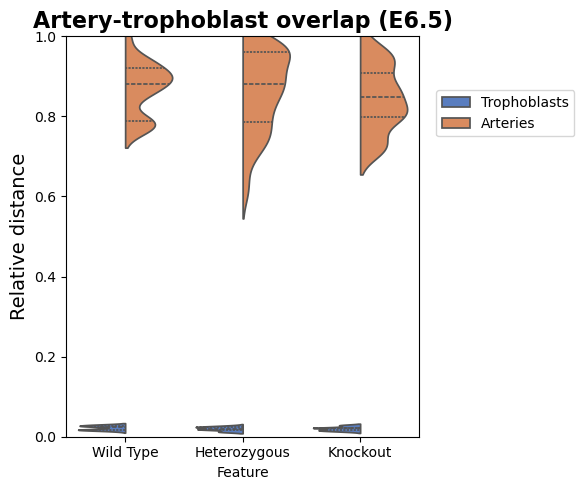

In [11]:
label_col = df.columns[0]
e65_columns = [label_col] + [col for col in df.columns if '(E6.5)' in str(col)]
df_e65 = df[e65_columns].copy()

df_artery = df_e65[df_e65[label_col].astype(str).str.strip() == 'artery'].drop(columns=[label_col])
df_tropho = df_e65[df_e65[label_col].astype(str).str.strip() == 'trophoblast'].drop(columns=[label_col])

def prep_long_data(data_subset, source_name):
    long_df = data_subset.melt(var_name='Raw_Column', value_name='Value').dropna()
    long_df['Value'] = pd.to_numeric(long_df['Value'], errors='coerce').clip(lower=0)
    long_df.dropna(subset=['Value'], inplace=True)
    long_df['Feature'] = long_df['Raw_Column'].apply(lambda x: re.sub(r' \(E6\.5\)(\.\d+)?$', '', str(x)))
    long_df['Source'] = source_name
    return long_df

df_long_tropho = prep_long_data(df_tropho, 'Trophoblasts')
df_long_artery = prep_long_data(df_artery, 'Arteries')

plot_data_balanced = pd.concat([df_long_tropho, df_long_artery], ignore_index=True)

custom_order = ["Wild Type", "Heterozygous", "Knockout"]
present_features = plot_data_balanced['Feature'].unique()
ordered_shared_columns = [col for col in custom_order if col in present_features]


plt.figure(figsize=(6, 5))
sns.violinplot(
    x="Feature", y="Value", hue="Source",
    data=plot_data_balanced, scale="width", inner="quart", split=True,
    order=ordered_shared_columns, palette="muted"
)

plt.ylim(bottom=0, top=1)
plt.title(f"Artery-trophoblast overlap (E6.5)", fontsize=16, weight="bold")
plt.ylabel("Relative distance", fontsize=14)
plt.legend(loc=(1.05, 0.75))
plt.tight_layout()
plt.savefig("e6-5_artery_trophoblast.pdf", dpi=300, format="pdf", bbox_inches='tight')
plt.show()

<h2>Figure 5F</h2>

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9238/2501360939.py:26: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


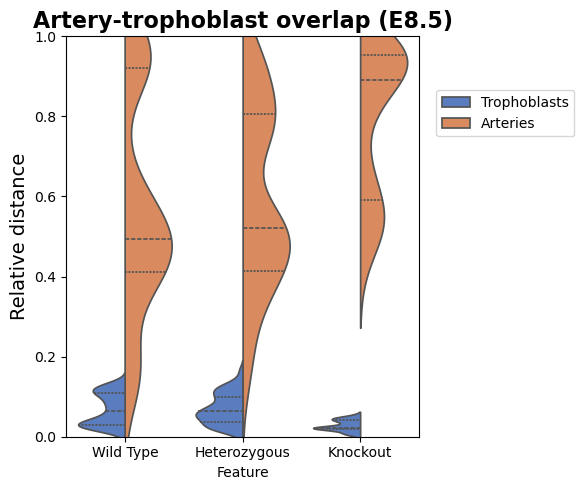

In [12]:
label_col = df.columns[0]
e85_columns = [label_col] + [col for col in df.columns if '(E8.5)' in str(col)]
df_e85 = df[e85_columns].copy()

df_artery = df_e85[df_e85[label_col].astype(str).str.strip() == 'artery'].drop(columns=[label_col])
df_tropho = df_e85[df_e85[label_col].astype(str).str.strip() == 'trophoblast'].drop(columns=[label_col])

def prep_long_data_e85(data_subset, source_name):
    long_df = data_subset.melt(var_name='Raw_Column', value_name='Value').dropna()
    long_df['Value'] = pd.to_numeric(long_df['Value'], errors='coerce').clip(lower=0)
    long_df.dropna(subset=['Value'], inplace=True)
    long_df['Feature'] = long_df['Raw_Column'].apply(lambda x: re.sub(r' \(E8\.5\)(\.\d+)?$', '', str(x)))
    long_df['Source'] = source_name
    return long_df

df_long_tropho = prep_long_data_e85(df_tropho, 'Trophoblasts')
df_long_artery = prep_long_data_e85(df_artery, 'Arteries')

plot_data_balanced = pd.concat([df_long_tropho, df_long_artery], ignore_index=True)

custom_order = ["Wild Type", "Heterozygous", "Knockout"]
present_features = plot_data_balanced['Feature'].unique()
ordered_shared_columns = [col for col in custom_order if col in present_features]

plt.figure(figsize=(6, 5))
sns.violinplot(
    x="Feature", y="Value", hue="Source",
    data=plot_data_balanced, scale="width", inner="quart", split=True,
    order=ordered_shared_columns, palette="muted"
)

plt.ylim(bottom=0, top=1)
plt.title(f"Artery-trophoblast overlap (E8.5)", fontsize=16, weight="bold")
plt.ylabel("Relative distance", fontsize=14)
plt.legend(loc=(1.05, 0.75))
plt.tight_layout()
plt.savefig("e8-5_artery_trophoblast.pdf", dpi=300, format="pdf", bbox_inches='tight')
plt.show()

<h2> Statistical Tests</h2>

In [13]:
print("Kolmogorov-Smirnov Test (E6.5)")

genetic_comparisons = [('Wild Type', 'Heterozygous'), ('Wild Type', 'Knockout')]
cell_types = ['Arteries', 'Trophoblasts']
x_grid = np.linspace(0, 1.2, 2000)

def get_mean_ecdf(df_source, feature, x_grid):
    reps = df_source[df_source['Feature'] == feature]['Raw_Column'].unique()
    ecdfs = []
    for rep in reps:
        vals = df_source[df_source['Raw_Column'] == rep]['Value'].values
        if len(vals) > 0:
            ecdf = ECDF(vals)(x_grid) 
            ecdfs.append(ecdf)
    if ecdfs:
        return np.mean(ecdfs, axis=0), len(ecdfs) 
    return None, 0

for cell_type in cell_types:
    print(f"--- {cell_type.upper()} ---")
    df_cell = df_long_tropho if cell_type == 'Trophoblasts' else df_long_artery
    p_values, valid_comps = [], []
    
    for control, test in genetic_comparisons:
        cdf_control, n_control = get_mean_ecdf(df_cell, control, x_grid)
        cdf_test, n_test = get_mean_ecdf(df_cell, test, x_grid)
        
        if n_control > 0 and n_test > 0:
            D = np.max(np.abs(cdf_control - cdf_test))
            
            en = (n_control * n_test) / (n_control + n_test)
            
            p_val = kstwo.sf(D, np.round(en))
            p_values.append(p_val)
            valid_comps.append((control, test, D, n_control, n_test))
            
    if p_values:
        _, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
        for i, (control, test, D, n_c, n_t) in enumerate(valid_comps):
            p_val = pvals_corrected[i]
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            print(f"  {control} (N={n_c}) vs {test} (N={n_t}):")
            print(f"     Average D = {D:.4f} | Corrected p = {p_val:.4f} ({sig})\n")
    else:
        print("  No data available for testing.\n")

Kolmogorov-Smirnov Test (E6.5)
--- ARTERIES ---
  Wild Type (N=9) vs Heterozygous (N=8):
     Average D = 0.2182 | Corrected p = 1.0000 (ns)

  Wild Type (N=9) vs Knockout (N=7):
     Average D = 0.5068 | Corrected p = 0.3534 (ns)

--- TROPHOBLASTS ---
  Wild Type (N=9) vs Heterozygous (N=8):
     Average D = 0.1640 | Corrected p = 1.0000 (ns)

  Wild Type (N=9) vs Knockout (N=7):
     Average D = 0.5458 | Corrected p = 0.2445 (ns)



In [14]:
print("Kolmogorov-Smirnov Test (E8.5)")

genetic_comparisons = [('Wild Type', 'Heterozygous'), ('Wild Type', 'Knockout')]
cell_types = ['Arteries', 'Trophoblasts']
x_grid = np.linspace(0, 1.2, 2000)

def get_mean_ecdf(df_source, feature, x_grid):
    reps = df_source[df_source['Feature'] == feature]['Raw_Column'].unique()
    ecdfs = []
    for rep in reps:
        vals = df_source[df_source['Raw_Column'] == rep]['Value'].values
        if len(vals) > 0:
            ecdf = ECDF(vals)(x_grid) 
            ecdfs.append(ecdf)
    if ecdfs:
        return np.mean(ecdfs, axis=0), len(ecdfs)
    return None, 0

for cell_type in cell_types:
    print(f"--- {cell_type.upper()} ---")
    df_cell = df_long_tropho if cell_type == 'Trophoblasts' else df_long_artery
    p_values, valid_comps = [], []
    
    for control, test in genetic_comparisons:
        cdf_control, n_control = get_mean_ecdf(df_cell, control, x_grid)
        cdf_test, n_test = get_mean_ecdf(df_cell, test, x_grid)
        
        if n_control > 0 and n_test > 0:
            D = np.max(np.abs(cdf_control - cdf_test))
            
            en = (n_control * n_test) / (n_control + n_test)
            
            p_val = kstwo.sf(D, np.round(en))
            p_values.append(p_val)
            valid_comps.append((control, test, D, n_control, n_test))
            
    if p_values:
        _, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')
        for i, (control, test, D, n_c, n_t) in enumerate(valid_comps):
            p_val = pvals_corrected[i]
            sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            print(f"  {control} (N={n_c}) vs {test} (N={n_t}):")
            print(f"     Average D = {D:.4f} | Corrected p = {p_val:.4f} ({sig})\n")
    else:
        print("  No data available for testing.\n")

Kolmogorov-Smirnov Test (E8.5)
--- ARTERIES ---
  Wild Type (N=9) vs Heterozygous (N=8):
     Average D = 0.2182 | Corrected p = 1.0000 (ns)

  Wild Type (N=9) vs Knockout (N=7):
     Average D = 0.5068 | Corrected p = 0.3534 (ns)

--- TROPHOBLASTS ---
  Wild Type (N=9) vs Heterozygous (N=8):
     Average D = 0.1640 | Corrected p = 1.0000 (ns)

  Wild Type (N=9) vs Knockout (N=7):
     Average D = 0.5458 | Corrected p = 0.2445 (ns)



<h2>Figure 5G</h2>

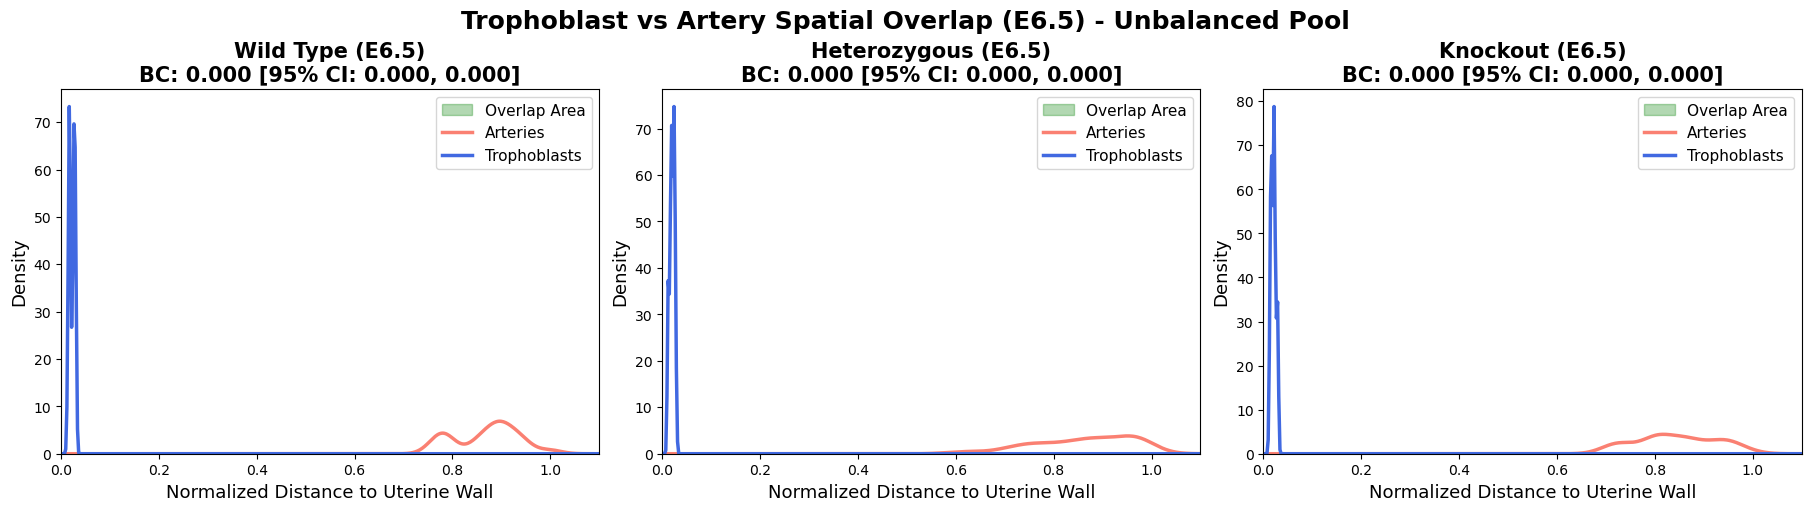

In [15]:
import random
random.seed(44)
target_stage = "E6.5"
label_col = df.columns[0]
stage_columns = [label_col] + [col for col in df.columns if f'({target_stage})' in str(col)]
df_stage = df[stage_columns].copy()

df_artery = df_stage[df_stage[label_col].astype(str).str.strip() == 'artery'].drop(columns=[label_col])
df_tropho = df_stage[df_stage[label_col].astype(str).str.strip() == 'trophoblast'].drop(columns=[label_col])

def prep_raw_data(data_subset):
    """Melts and cleans the data into a raw, unbalanced pool of all cells"""
    long_df = data_subset.melt(var_name='Raw_Column', value_name='Value').dropna()
    long_df['Value'] = pd.to_numeric(long_df['Value'], errors='coerce').clip(lower=0)
    long_df.dropna(subset=['Value'], inplace=True)
    long_df['Feature'] = long_df['Raw_Column'].apply(lambda x: re.sub(rf' \({target_stage}\)(\.\d+)?$', '', str(x)))
    return long_df

pool_artery = prep_raw_data(df_artery)
pool_tropho = prep_raw_data(df_tropho)


genotypes = ["Wild Type", "Heterozygous", "Knockout"]
x_grid = np.linspace(0, 1.2, 500) 

def calc_bc(d1, d2):
    """Calculates Bhattacharyya Coefficient rapidly using grid integration"""
    k1 = gaussian_kde(d1)(x_grid)
    k2 = gaussian_kde(d2)(x_grid)
    return np.trapz(np.sqrt(k1 * k2), x_grid)

results = {}
n_bootstraps = 1000

fig, axes = plt.subplots(1, len(genotypes), figsize=(18, 5), constrained_layout=True)

for i, genotype in enumerate(genotypes):
    art_vals = pool_artery[pool_artery['Feature'] == genotype]['Value'].values
    tropho_vals = pool_tropho[pool_tropho['Feature'] == genotype]['Value'].values
    
    if len(art_vals) > 1 and len(tropho_vals) > 1:
        kde_art = gaussian_kde(art_vals)(x_grid)
        kde_tropho = gaussian_kde(tropho_vals)(x_grid)
        bc_obs = calc_bc(art_vals, tropho_vals)
        
        boot_bcs = []
        for _ in range(n_bootstraps):
            s_art = np.random.choice(art_vals, size=len(art_vals), replace=True)
            s_tropho = np.random.choice(tropho_vals, size=len(tropho_vals), replace=True)
            boot_bcs.append(calc_bc(s_art, s_tropho))
            
        ci_low = np.percentile(boot_bcs, 2.5)
        ci_high = np.percentile(boot_bcs, 97.5)
        
        results[genotype] = {'BC': bc_obs, 'CI_L': ci_low, 'CI_H': ci_high}
        
        ax = axes[i]
        overlap = np.minimum(kde_art, kde_tropho)
        
        ax.fill_between(x_grid, overlap, color='green', alpha=0.3, label='Overlap Area')
        ax.plot(x_grid, kde_art, color='salmon', lw=2.5, label='Arteries')
        ax.plot(x_grid, kde_tropho, color='royalblue', lw=2.5, label='Trophoblasts')
        
        ax.set_title(f"{genotype} ({target_stage})\nBC: {bc_obs:.3f} [95% CI: {ci_low:.3f}, {ci_high:.3f}]", fontsize=15, weight='bold')
        ax.set_xlim(0, 1.1)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Normalized Distance to Uterine Wall", fontsize=13)
        ax.set_ylabel("Density", fontsize=13)
        ax.legend(fontsize=11)

plt.suptitle(f"Trophoblast vs Artery Spatial Overlap ({target_stage}) - Unbalanced Pool", fontsize=18, weight='bold')
plt.savefig(f"BC_KDE_overlap_plots_unbalanced_{target_stage}.pdf", dpi=300)
plt.show()

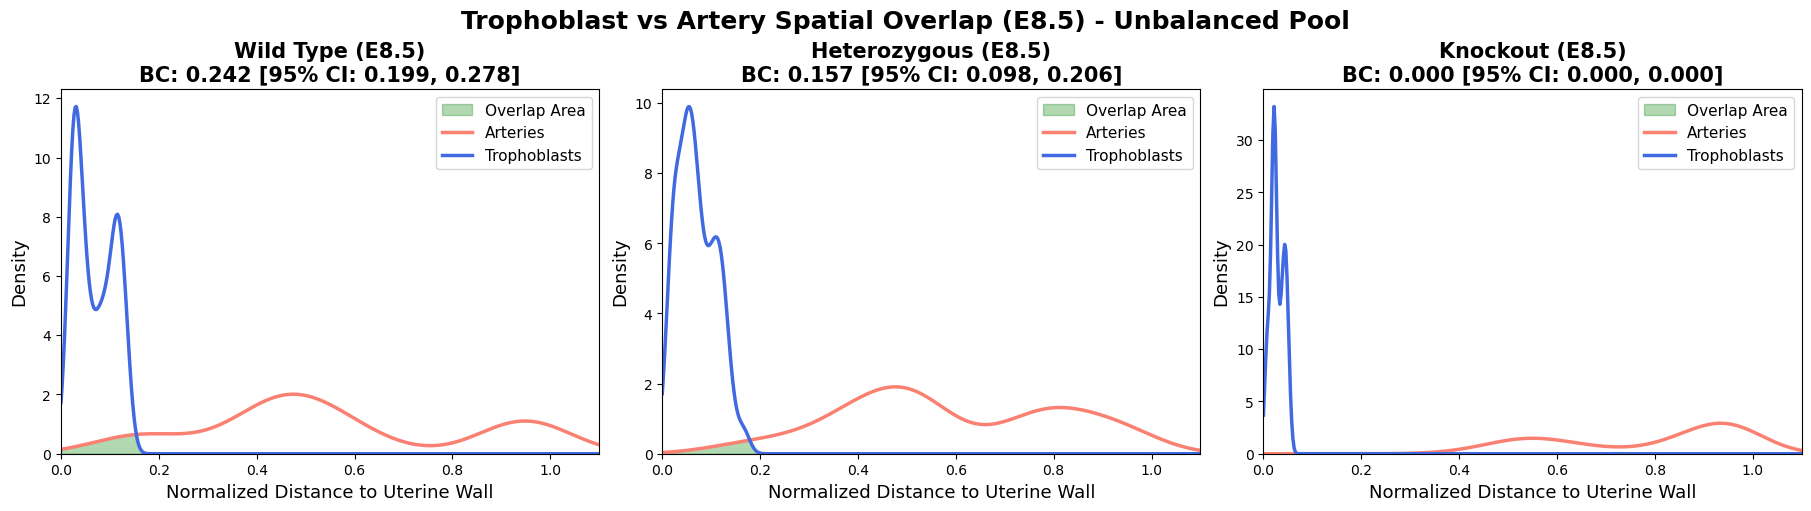

In [16]:
random.seed(44)
target_stage = "E8.5"

df = pd.read_excel(file_path, sheet_name="Fig_5D+F+G")
label_col = df.columns[0]

stage_columns = [label_col] + [col for col in df.columns if f'({target_stage})' in str(col)]
df_stage = df[stage_columns].copy()

df_artery = df_stage[df_stage[label_col].astype(str).str.strip() == 'artery'].drop(columns=[label_col])
df_tropho = df_stage[df_stage[label_col].astype(str).str.strip() == 'trophoblast'].drop(columns=[label_col])

def prep_raw_data(data_subset):
    """Melts and cleans the data into a raw, unbalanced pool of all cells"""
    long_df = data_subset.melt(var_name='Raw_Column', value_name='Value').dropna()
    long_df['Value'] = pd.to_numeric(long_df['Value'], errors='coerce').clip(lower=0)
    long_df.dropna(subset=['Value'], inplace=True)
    long_df['Feature'] = long_df['Raw_Column'].apply(lambda x: re.sub(rf' \({target_stage}\)(\.\d+)?$', '', str(x)))
    return long_df

pool_artery = prep_raw_data(df_artery)
pool_tropho = prep_raw_data(df_tropho)

genotypes = ["Wild Type", "Heterozygous", "Knockout"]
x_grid = np.linspace(0, 1.2, 500)

def calc_bc(d1, d2):
    """Calculates Bhattacharyya Coefficient rapidly using grid integration"""
    k1 = gaussian_kde(d1)(x_grid)
    k2 = gaussian_kde(d2)(x_grid)
    return np.trapz(np.sqrt(k1 * k2), x_grid)

results = {}
n_bootstraps = 1000

fig, axes = plt.subplots(1, len(genotypes), figsize=(18, 5), constrained_layout=True)


for i, genotype in enumerate(genotypes):
    art_vals = pool_artery[pool_artery['Feature'] == genotype]['Value'].values
    tropho_vals = pool_tropho[pool_tropho['Feature'] == genotype]['Value'].values
    
    if len(art_vals) > 1 and len(tropho_vals) > 1:
        kde_art = gaussian_kde(art_vals)(x_grid)
        kde_tropho = gaussian_kde(tropho_vals)(x_grid)
        bc_obs = calc_bc(art_vals, tropho_vals)
        
        boot_bcs = []
        for _ in range(n_bootstraps):
            s_art = np.random.choice(art_vals, size=len(art_vals), replace=True)
            s_tropho = np.random.choice(tropho_vals, size=len(tropho_vals), replace=True)
            boot_bcs.append(calc_bc(s_art, s_tropho))
            
        ci_low = np.percentile(boot_bcs, 2.5)
        ci_high = np.percentile(boot_bcs, 97.5)
        
        results[genotype] = {'BC': bc_obs, 'CI_L': ci_low, 'CI_H': ci_high}
        
        ax = axes[i]
        overlap = np.minimum(kde_art, kde_tropho)
        
        ax.fill_between(x_grid, overlap, color='green', alpha=0.3, label='Overlap Area')
        ax.plot(x_grid, kde_art, color='salmon', lw=2.5, label='Arteries')
        ax.plot(x_grid, kde_tropho, color='royalblue', lw=2.5, label='Trophoblasts')
        
        ax.set_title(f"{genotype} ({target_stage})\nBC: {bc_obs:.3f} [95% CI: {ci_low:.3f}, {ci_high:.3f}]", fontsize=15, weight='bold')
        ax.set_xlim(0, 1.1)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Normalized Distance to Uterine Wall", fontsize=13)
        ax.set_ylabel("Density", fontsize=13)
        ax.legend(fontsize=11)

plt.suptitle(f"Trophoblast vs Artery Spatial Overlap ({target_stage}) - Unbalanced Pool", fontsize=18, weight='bold')
plt.savefig(f"BC_KDE_overlap_plots_unbalanced_{target_stage}.pdf", dpi=300)
plt.show()

/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9238/2539937808.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(
/var/folders/_f/bpy6fhdd6gl4dz0hvfq6l9880000gn/T/ipykernel_9238/2539937808.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(


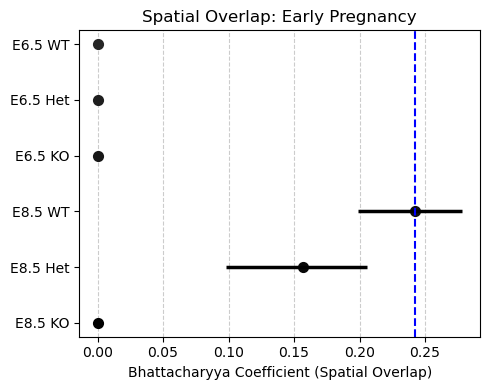

In [17]:
data = {
    'E6.5': {
        'WT': {'median': 0.00, 'lower': 0.00, 'upper': 0.00},
        'Het': {'median': 0.00, 'lower': 0.00, 'upper': 0.00},
        'KO': {'median': 0.00, 'lower': 0.00, 'upper': 0.00}
    },
    'E8.5': {
        'WT': {'median': 0.242, 'lower': 0.199, 'upper': 0.278},
        'Het': {'median': 0.157, 'lower': 0.098, 'upper': 0.206},
        'KO': {'median': 0.00, 'lower': 0.00, 'upper': 0.00}
    }
}

rows = []
for age, genotypes in data.items():
    for genotype, vals in genotypes.items():
        rows.append({
            'Age': age,
            'Genotype': genotype,
            'BC': vals['median'],
            'Lower': vals['lower'],
            'Upper': vals['upper'],
            'Label': f"{age} {genotype}"
        })

df = pd.DataFrame(rows)

plt.figure(figsize=(5, 4))


errors = [df['BC'] - df['Lower'], df['Upper'] - df['BC']]

ax = sns.pointplot(
    data=df, 
    x="BC", 
    y="Label",
    palette="dark:black",
    join=False,
    markers="o",
    markersize = 6, 
)

plt.errorbar(linewidth = 2.5, x=df['BC'], y=df['Label'], xerr=errors, fmt='none', c='black', capsize=0)

ax.set_xlabel('Bhattacharyya Coefficient (Spatial Overlap)')
ax.set_ylabel('')
ax.xaxis.grid(True, linestyle='--', color='gray', alpha=0.4, zorder=0)
ax.set_title('Spatial Overlap: Early Pregnancy')
ax.axvline(x=0.242, color='blue', linestyle='--', alpha=1, linewidth=1.5)

plt.tight_layout()
plt.savefig(f"forest_plot_early_pregnancy.pdf", dpi=300)
plt.show()